In [33]:
import pandas as pd
import numpy as np

In [34]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "processed_timeseries_table_timeseries_table " + "(10)" + ".csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "lsobieski/processed-thermostat-data",
  file_path,
)

df.head()

,Timestamp,Temperature,Setpoint,FanState,OutputState,CumulativeRuntime,CumulativeCost,RunningMode_cool,RunningMode_heat,RunningMode_off,Outdoor_Temperature,outsideMinTemp,outsideMaxTemp,outsideHumidity
0,2025-02-13 12:32:53,24.150,24.44,0.0,0.0,0.0,0.000000,0.0,0.0,1.0,0.052000,-1.44,0.58,71.0
1,2025-02-13 12:33:29,23.860,24.44,1.0,1.0,0.0,0.000000,0.0,1.0,0.0,0.064000,-1.44,0.58,71.0
2,2025-02-13 12:33:35,23.700,24.44,1.0,1.0,6.0,0.000850,0.0,1.0,0.0,0.066000,-1.44,0.58,71.0
3,2025-02-13 12:34:04,23.540,24.44,1.0,1.0,35.0,0.004958,0.0,1.0,0.0,0.075667,-1.44,0.58,71.0
4,2025-02-13 12:34:40,23.395,24.44,1.0,1.0,71.0,0.010058,0.0,1.0,0.0,0.087667,-1.44,0.58,71.0


In [35]:
df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()

In [36]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Date'] = df['Timestamp'].dt.date

In [37]:
df["CumulativeRuntime"].dtype

dtype('float64')

In [38]:
daily_data = df.groupby('Date').agg(
    #should have a check for if running from before midnight to next day
    runtime_start=('CumulativeRuntime', 'first'),
    runtime_end=('CumulativeRuntime', 'last'),

    avg_setpoint=('Setpoint', 'mean'),
    #fix this through interpolation later but for now ok
    temp_at_midnight=('Temperature', 'first'),
    #
    outdoor_temp_at_midnight=('Outdoor_Temperature', 'first'),
    outdoor_humidity_at_midnight=('outsideHumidity', 'first'),
)

daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]

daily_data.head()
    

,runtime_start,runtime_end,avg_setpoint,temp_at_midnight,outdoor_temp_at_midnight,outdoor_humidity_at_midnight,daily_runtime
Date,,,,,,,
2025-02-13,0.0,26694.0,24.440000,24.150000,0.052000,71.0,26694.0
2025-02-14,26694.0,85709.0,24.440000,22.500000,-5.524561,89.0,59015.0
2025-02-15,86248.0,119776.0,24.440000,20.503333,7.042472,63.0,33528.0
2025-02-16,119776.0,165910.0,24.440000,20.690000,12.536759,97.0,46134.0
2025-02-17,166569.0,222586.0,23.567797,20.310000,-2.420000,70.0,56017.0


In [39]:
daily_data.isnull().sum()

runtime_start                   0
runtime_end                     0
avg_setpoint                    0
temp_at_midnight                0
outdoor_temp_at_midnight        0
outdoor_humidity_at_midnight    0
daily_runtime                   0
dtype: int64

In [40]:
daily_data.shape

(340, 7)

In [41]:
daily_data = daily_data.drop(columns = ["runtime_start", "runtime_end"])


In [42]:
daily_data['day_gap'] = daily_data.index.to_series().diff().dt.days
gaps = daily_data[daily_data['day_gap'] != 1]
gaps

,avg_setpoint,temp_at_midnight,outdoor_temp_at_midnight,outdoor_humidity_at_midnight,daily_runtime,day_gap
Date,,,,,,
2025-02-13,24.44,24.15,0.052000,71.0,26694.0,NaN
2026-01-08,21.11,21.08,10.926889,97.0,0.0,28.0
2026-02-18,21.11,21.08,-4.210000,90.0,0.0,14.0


In [43]:
daily_data.index = pd.to_datetime(daily_data.index)
daily_data = daily_data.loc[:'2026-01-07']
daily_data.shape

(302, 6)

In [44]:
target = 'daily_runtime'

daily_data['avg_setpoint_lagged'] = daily_data['avg_setpoint'].shift(1)

In [45]:
daily_data.isnull().sum()

avg_setpoint                    0
temp_at_midnight                0
outdoor_temp_at_midnight        0
outdoor_humidity_at_midnight    0
daily_runtime                   0
day_gap                         1
avg_setpoint_lagged             1
dtype: int64

In [46]:
#drop places that are missing a lagged setpoint (position 1)
daily_data = daily_data.dropna()

In [47]:
#rolling window params
window_size = 21

In [48]:
# need to add weather data here
X = daily_data[['avg_setpoint_lagged', 'temp_at_midnight', 'outdoor_temp_at_midnight', 'outdoor_humidity_at_midnight']].values
y = daily_data['daily_runtime'].values
dates = daily_data.index

windows = []

for end in range(window_size, len(daily_data) - 1 + 1):
    start = end - window_size

    X_train = X[start:end]
    y_train = y[start:end]
    
    X_test = X[end:end + 1]
    y_test = y[end:end + 1]
    
    test_date = dates[end]
    
    windows.append((X_train, y_train, X_test, y_test, test_date))

In [49]:
from sklearn.linear_model import LinearRegression

predictions = []

for X_train, y_train, X_test, y_test, test_date in windows:
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)[0]
    
    predictions.append({
        'Date': test_date,
        'y_true': y_test[0],
        'y_pred': y_pred
    })
    
pred_df = pd.DataFrame(predictions)
pred_df.head()

,Date,y_true,y_pred
0,2025-03-07,10354.0,29601.364002
1,2025-03-08,4537.0,4851.362945
2,2025-03-09,6697.0,17753.658623
3,2025-03-10,9896.0,18774.376950
4,2025-03-11,2436.0,8008.993771


In [50]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])
print("MSE:",mse) 

print("RMSE:", np.sqrt(mse))

MSE: 112212752.23129703
RMSE: 10593.052073472358


<Axes: title={'center': 'Rolling Window Prediction'}>

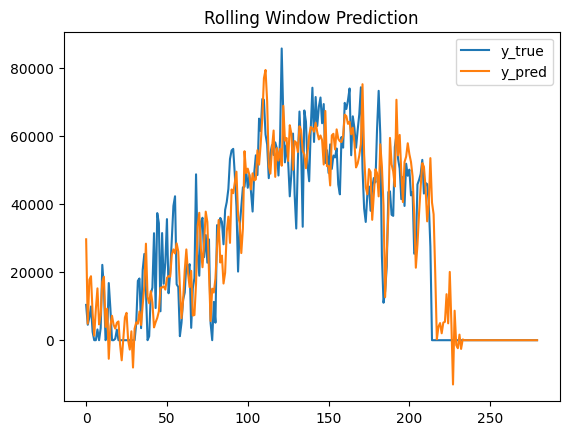

In [51]:
pred_df[['y_true', 'y_pred']].plot(title='Rolling Window Prediction')

In [52]:
y_true = pred_df["y_true"].to_numpy()
y_pred = pred_df["y_pred"].to_numpy()

In [53]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
)

In [54]:
mae = mean_absolute_error(y_true, y_pred)
medae = np.median(np.abs(y_true - y_pred))
maxae = np.max(np.abs(y_true - y_pred))

In [55]:
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) / denom)

def mape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return 100.0 * np.mean(np.abs((y_true - y_pred) / (y_true + eps)))

In [56]:
# Relative / % metrics
mape_val = mape(y_true, y_pred)
smape_val = smape(y_true, y_pred)

In [57]:
r2 = r2_score(y_true, y_pred)
evs = explained_variance_score(y_true, y_pred)

In [58]:
metrics = pd.Series({
    "MSE": mse,
    "RMSE": np.sqrt(mse),
    "MAE": mae,
    "MedianAE": medae,
    "MaxAE": maxae,
    "MAPE (%)": mape_val,
    "sMAPE (%)": smape_val,
    "R2": r2,
    "ExplainedVariance": evs,
})

In [59]:
print("\n=== Model Evaluation (Rolling Predictions) ===")
display(metrics.to_frame("value"))


=== Model Evaluation (Rolling Predictions) ===


,value
MSE,1.122128e+08
RMSE,1.059305e+04
MAE,7.429011e+03
MedianAE,5.282447e+03
MaxAE,4.038897e+04
MAPE (%),1.054437e+13
sMAPE (%),5.113614e+01
R2,8.175532e-01
ExplainedVariance,8.182621e-01


# Generalization for all Data

In [28]:
mse_list = []
rmse_list = []
mae_list = []
medae_list = []
maxae_list = []
mape_list = []
smape_list = []
r2_list = []
evs_list = []

for i in range (1, 101):
    file_path = "processed_timeseries_table_timeseries_table (" + str(i) + ").csv"
    
    # Load the latest version
    df = kagglehub.dataset_load(
      KaggleDatasetAdapter.PANDAS,
      "lsobieski/processed-thermostat-data",
      file_path,
    )
    
    df.head()
    
    df["CumulativeRuntime"] = df["CumulativeRuntime"].ffill()
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Date'] = df['Timestamp'].dt.date
    
    daily_data = df.groupby('Date').agg(
        #should have a check for if running from before midnight to next day
        runtime_start=('CumulativeRuntime', 'first'),
        runtime_end=('CumulativeRuntime', 'last'),
    
        avg_setpoint=('Setpoint', 'mean'),
        #fix this through interpolation later but for now ok
        temp_at_midnight=('Temperature', 'first'),
        #
        outdoor_temp_at_midnight=('Outdoor_Temperature', 'first'),
        outdoor_humidity_at_midnight=('outsideHumidity', 'first'),
    )
    
    daily_data["daily_runtime"] = daily_data["runtime_end"] - daily_data["runtime_start"]
    daily_data = daily_data.drop(columns = ["runtime_start", "runtime_end"])
    daily_data['day_gap'] = daily_data.index.to_series().diff().dt.days

    
    groups = (daily_data['day_gap'] > 1).cumsum()
    largest_group = groups.value_counts().idxmax()
    daily_data = daily_data[groups == largest_group]

    target = 'daily_runtime'

    daily_data['avg_setpoint_lagged'] = daily_data['avg_setpoint'].shift(1)

    daily_data = daily_data.dropna()

    X = daily_data[['avg_setpoint_lagged', 'temp_at_midnight', 'outdoor_temp_at_midnight', 'outdoor_humidity_at_midnight']].values
    y = daily_data['daily_runtime'].values
    dates = daily_data.index
    
    windows = []

    if len(daily_data) < window_size:
        print(i)
        continue
    
    for end in range(window_size, len(daily_data) - 1 + 1):
        start = end - window_size
    
        X_train = X[start:end]
        y_train = y[start:end]
        
        X_test = X[end:end + 1]
        y_test = y[end:end + 1]
        
        test_date = dates[end]
        
        windows.append((X_train, y_train, X_test, y_test, test_date))

    predictions = []

    for X_train, y_train, X_test, y_test, test_date in windows:
        model = LinearRegression()
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)[0]
        
        predictions.append({
            'Date': test_date,
            'y_true': y_test[0],
            'y_pred': y_pred
        })
        
    pred_df = pd.DataFrame(predictions)

    mse = mean_squared_error(pred_df['y_true'], pred_df['y_pred'])

    y_true = pred_df["y_true"].to_numpy()
    y_pred = pred_df["y_pred"].to_numpy()

    mae = mean_absolute_error(y_true, y_pred)
    medae = np.median(np.abs(y_true - y_pred))
    maxae = np.max(np.abs(y_true - y_pred))

    mape_val = mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)

    r2 = r2_score(y_true, y_pred)
    evs = explained_variance_score(y_true, y_pred)

    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))
    mae_list.append(mae)
    medae_list.append(medae)
    maxae_list.append(maxae)
    mape_list.append(mape_val)
    smape_list.append(smape_val)
    r2_list.append(r2)
    evs_list.append(evs)

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
})

print(avg_metrics)

MSE                  3.279955e+32
RMSE                 2.566827e+15
MAE                  1.236652e+14
MedianAE             5.597791e+03
MaxAE                5.378427e+16
MAPE (%)             6.952927e+12
sMAPE (%)            5.915345e+01
R2                  -9.613946e+23
ExplainedVariance   -9.591838e+23
dtype: float64


In [29]:
print(r2_list)

[0.501408871809343, -0.1027760790698189, 0.8241679529627713, -2.731139719123991, 0.5401888441816797, 0.2944667199780864, 0.3557698584225458, 0.15130522973619442, 0.65088916927234, 0.8175531524603623, 0.3827129680149711, 0.3441868000026106, 0.4314099302626925, 0.16124495183987164, 0.11690986451076923, 0.17226337814932768, 0.6183200032045291, 0.21815894970427996, 0.2011562895488621, 0.6024562596226157, 0.18270073662537778, -0.16543002427380804, -0.224705146638555, 0.4189508016302922, 0.7713501000742305, 0.5596448412438946, 0.39062598939461257, -150.97490890362005, 0.6022124518577516, -0.42167849125006085, 0.5756922892429099, 0.4116065574420722, 0.28292539666080474, -0.43558422034334043, 0.04966885909296548, -1.206839892728707, 0.6010011985154029, 0.4811737351723543, 0.5484366397811569, 0.03904339162312276, -0.06235835336626727, 0.006893817688142123, 0.14151411974375994, -0.5399863476900435, 0.3444544755697726, 0.04463624245062048, 0.4375344598920514, 0.13194745901496174, 0.52405404099233

In [31]:
#looked at data for r^2 with wild outliers
#these outliers are created by "bad data" where the fan state (used to calculate runtime) isnt tracked properly
outlier_indices = [i for i, val in enumerate(r2_list) if val < -5]

In [32]:
all_metric_lists = {
    "mse": mse_list,
    "rmse": rmse_list,
    "mae": mae_list,
    "medae": medae_list,
    "maxae": maxae_list,
    "mape": mape_list,
    "smape": smape_list,
    "r2": r2_list,
    "evs": evs_list
}

filtered_data = {
    name: [val for i, val in enumerate(lst) if i not in outlier_indices]
    for name, lst in all_metric_lists.items()
}

mse_list = filtered_data["mse"]
rmse_list = filtered_data["rmse"]
mae_list = filtered_data["mae"]
medae_list = filtered_data["medae"]
maxae_list = filtered_data["maxae"]
mape_list = filtered_data["mape"]
smape_list = filtered_data["smape"]
r2_list = filtered_data["r2"]
evs_list = filtered_data["evs"]

avg_metrics = pd.Series({
    "MSE": np.mean(mse_list),
    "RMSE": np.mean(rmse_list),
    "MAE": np.mean(mae_list),
    "MedianAE": np.mean(medae_list),
    "MaxAE": np.mean(maxae_list),
    "MAPE (%)": np.mean(mape_list),
    "sMAPE (%)": np.mean(smape_list),
    "R2": np.mean(r2_list),
    "ExplainedVariance": np.mean(evs_list),
})

print(avg_metrics)

MSE                  2.212729e+08
RMSE                 1.355885e+04
MAE                  8.471400e+03
MedianAE             5.496839e+03
MaxAE                1.002439e+05
MAPE (%)             6.388496e+12
sMAPE (%)            5.875023e+01
R2                   3.660466e-01
ExplainedVariance    3.696242e-01
dtype: float64


<Axes: ylabel='Count'>

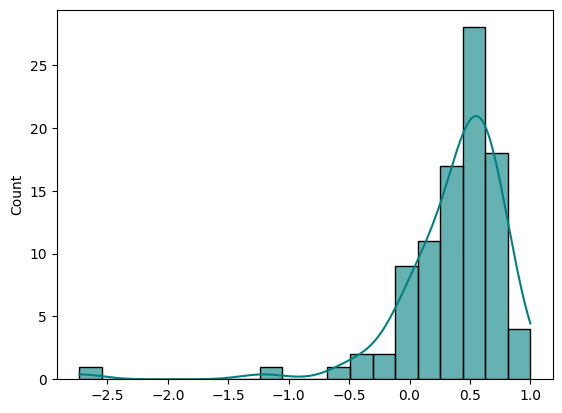

In [61]:
import seaborn as sns
sns.histplot(filtered_r2, bins=20, kde=True, color='teal', alpha=0.6)

In [ ]:
#still a couple outliers due to bad data, but better